# Load .csv file

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("hotel_bookings.csv")
# check dataset
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (119390, 32)
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2 

# Task 2: Comparative Analysis of Learning Paradigms

## 2.1 Learning Mechanism and Label Dependency

In [ ]:
# Cross-tabulation between reservation_status and the target
target_status = pd.crosstab(
    df["reservation_status"],
    df["is_canceled"]
)

print("Reservation status vs is_canceled:")
print(target_status)


# Check whether all cancelled and no-show bookings are coded as is_canceled = 1
cancelled_no_show_total = (
    target_status.loc["Canceled", 1]
    + target_status.loc["No-Show", 1]
)

positive_target_total = (df["is_canceled"] == 1).sum()

print("\nCanceled + No-Show records:", cancelled_no_show_total)
print("Total records with is_canceled = 1:", positive_target_total)


# Check whether all Check-Out records are coded as is_canceled = 0
checkout_total = target_status.loc["Check-Out", 0]
negative_target_total = (df["is_canceled"] == 0).sum()

print("\nCheck-Out records:", checkout_total)
print("Total records with is_canceled = 0:", negative_target_total)

Reservation status vs is_canceled:
is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207

Canceled + No-Show records: 44224
Total records with is_canceled = 1: 44224

Check-Out records: 75166
Total records with is_canceled = 0: 75166


## 2.2 Data Requirements

In [ ]:
# Estimted dimensionality after leakage removal and one-hot encoding

exclude_features = [
    "is_canceled",
    "reservation_status",
    "reservation_status_date",
    "booking_changes",
    "days_in_waiting_list",
    "assigned_room_type"
]

X_temp = df.drop(columns=exclude_features)

# Object/category columns
categorical_features = list(
    X_temp.select_dtypes(include=["object", "category"]).columns
)

# These are numeric in storage, but categorical in meaning
for col in ["agent", "company"]:
    if col in X_temp.columns and col not in categorical_features:
        categorical_features.append(col)

# Remaining columns
non_categorical_features = [
    col for col in X_temp.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNon-categorical features:")
print(non_categorical_features)

encoded_columns = 0

"""
1. count how many unique categories each categorical variable has.
2. assume one dummy column per category.
3. add those dummy columns to the remaining numerical features.
"""
for col in categorical_features:
    n_categories = X_temp[col].nunique(dropna=False)
    encoded_columns += n_categories
    print(f"{col}: {n_categories} categories")

approx_total_features = (
    len(non_categorical_features)
    + encoded_columns
)

print("\nNumber of non-categorical features:",
      len(non_categorical_features))

print("Approx. one-hot columns:",
      encoded_columns)

print("Approx. total features after encoding:",
      approx_total_features)

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'agent', 'company']

Non-categorical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
hotel: 2 categories
arrival_date_month: 12 categories
meal: 5 categories
country: 178 categories
market_segment: 8 categories
distribution_channel: 5 categories
reserved_room_type: 10 categories
deposit_type: 3 categories
customer_type: 4 categories
agent: 334 categories
company: 353 categories

Number of non-categorical features: 15
Approx. one-hot columns: 914
Approx. total features after encoding: 929


## 2.3 Scalability and Computational Complexity


In [ ]:
# compare numerical ranges
features = [
    "adr",
    "total_of_special_requests"
]
for col in features:
    print(
        f"{col}: min = {df[col].min()}, "
        f"max = {df[col].max()}"
    )

adr: min = -6.38, max = 5400.0
total_of_special_requests: min = 0, max = 5


# Task 3: Critical Analysis of Data Quality
## 3.1 Missing Value Analysis

In [ ]:
# missing value summary

missing_summary = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Missing (%)": df.isna().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["Missing values"] > 0]
    .sort_values("Missing (%)", ascending=False)
    .round(3)
)

print(missing_summary)

          Missing values  Missing (%)
company           112593       94.307
agent              16340       13.686
country              488        0.409
children               4        0.003


In [ ]:
# check whether agent/company missingness differs by market segment

missing_by_segment = pd.DataFrame({
    "Agent missing (%)":
        df.groupby("market_segment")["agent"]
          .apply(lambda x: x.isna().mean() * 100),

    "Company missing (%)":
        df.groupby("market_segment")["company"]
          .apply(lambda x: x.isna().mean() * 100)
}).round(2)

print(missing_by_segment)

                Agent missing (%)  Company missing (%)
market_segment                                        
Aviation                    89.45                10.55
Complementary               86.14                57.87
Corporate                   86.76                15.56
Direct                      47.65                98.35
Groups                      20.94                92.98
Offline TA/TO                1.61                99.56
Online TA                    0.62                99.83
Undefined                  100.00               100.00


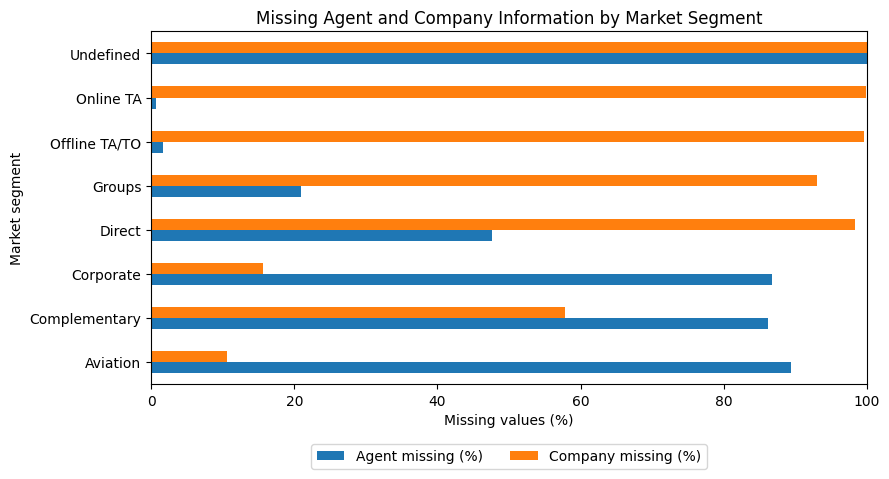

In [ ]:
# chart representation
missing_by_segment = pd.DataFrame({
    "Agent missing (%)":
        df.groupby("market_segment")["agent"]
          .apply(lambda x: x.isna().mean() * 100),

    "Company missing (%)":
        df.groupby("market_segment")["company"]
          .apply(lambda x: x.isna().mean() * 100)
}).round(2)

# Plot the chart
ax = missing_by_segment.plot(
    kind="barh",
    figsize=(9, 5)
)

ax.set_title("Missing Agent and Company Information by Market Segment")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Market segment")
ax.set_xlim(0, 100)

# Put legend below the graph
ax.legend(
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

# Leave enough space for legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

plt.show()

## 3.1 Duplicates

In [ ]:
# exact duplicate summary
duplicates_removed = df.duplicated().sum()
rows_in_duplicate_groups = df.duplicated(keep=False).sum()

duplicate_summary = pd.DataFrame({
    "Measure": [
        "Total rows",
        "Rows involved in duplicate groups",
        "Rows removed by drop_duplicates()",
        "Unique rows remaining"
    ],
    "Count": [
        len(df),
        rows_in_duplicate_groups,
        duplicates_removed,
        len(df.drop_duplicates())
    ],
    "Percentage (%)": [
        100,
        rows_in_duplicate_groups / len(df) * 100,
        duplicates_removed / len(df) * 100,
        len(df.drop_duplicates()) / len(df) * 100
    ]
})

duplicate_summary["Percentage (%)"] = duplicate_summary["Percentage (%)"].round(2)
print(duplicate_summary.to_string(index=False))

                          Measure  Count  Percentage (%)
                       Total rows 119390          100.00
Rows involved in duplicate groups  40165           33.64
Rows removed by drop_duplicates()  31994           26.80
            Unique rows remaining  87396           73.20


## 3.2 Outliers, Noise, Feature Distributions and Skewness

In [ ]:
# Distribution and skewness summary

features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

distribution_summary = pd.DataFrame({
    "Mean": df[features].mean(),
    "Median": df[features].median(),
    "Skewness": df[features].skew(),
    "Zero (%)": (df[features].eq(0).mean() * 100)
}).round(2)

print("Numerical Distribution Summary")
print(distribution_summary)

Numerical Distribution Summary
                                  Mean  Median  Skewness  Zero (%)
lead_time                       104.01   69.00      1.35      5.31
stays_in_weekend_nights           0.93    1.00      1.38     43.55
stays_in_week_nights              2.50    2.00      2.86      6.40
adults                            1.86    2.00     18.32      0.34
children                          0.10    0.00      4.11     92.80
babies                            0.01    0.00     24.65     99.23
previous_cancellations            0.09    0.00     24.46     94.57
previous_bookings_not_canceled    0.14    0.00     23.54     96.97
booking_changes                   0.22    0.00      6.00     84.86
days_in_waiting_list              2.32    0.00     11.94     96.90
adr                             101.83   94.58     10.53      1.64
required_car_parking_spaces       0.06    0.00      4.16     93.79
total_of_special_requests         0.57    0.00      1.35     58.90


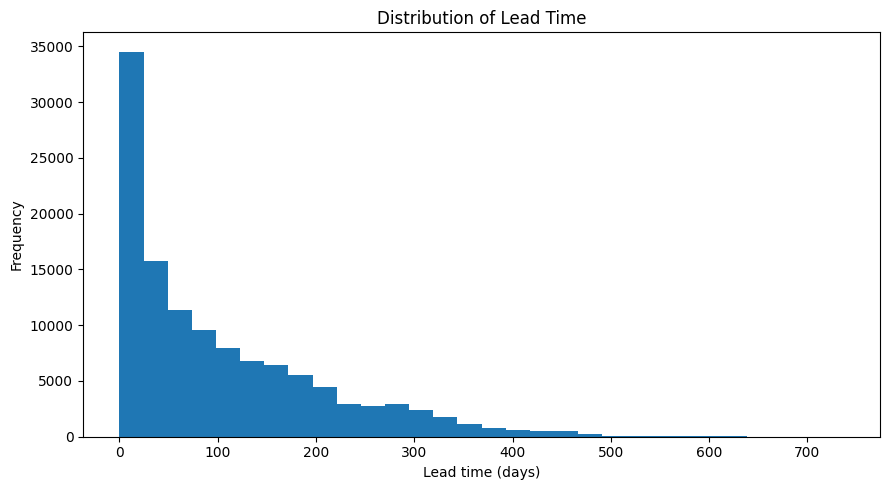

In [ ]:
# selected feature distributions
# lead time
plt.figure(figsize=(9, 5))
plt.hist(df["lead_time"].dropna(), bins=30)
plt.title("Distribution of Lead Time")
plt.xlabel("Lead time (days)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

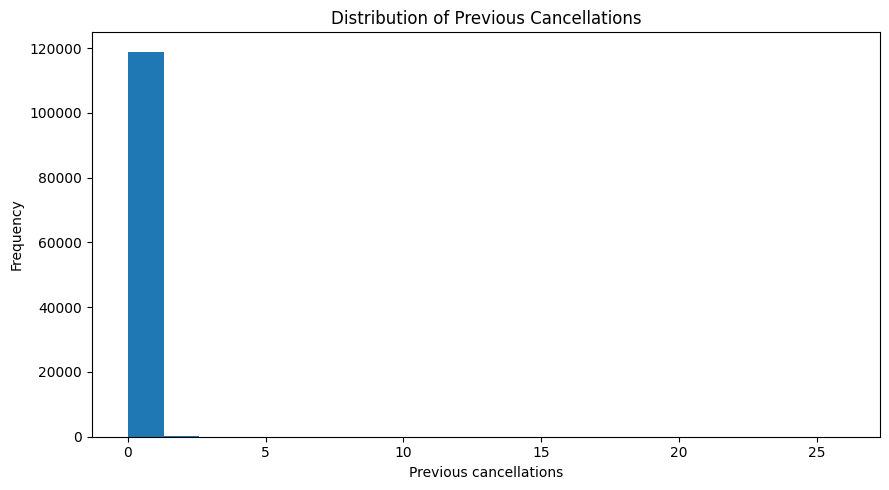

In [ ]:
# previous cancellations
plt.figure(figsize=(9, 5))
plt.hist(df["previous_cancellations"].dropna(), bins=20)
plt.title("Distribution of Previous Cancellations")
plt.xlabel("Previous cancellations")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

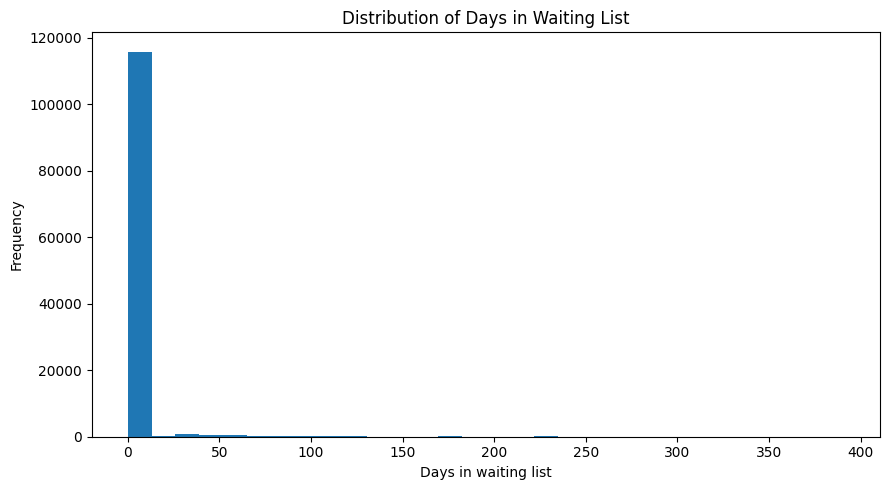

In [ ]:
# days in waiting list
plt.figure(figsize=(9, 5))
plt.hist(df["days_in_waiting_list"].dropna(), bins=30)
plt.title("Distribution of Days in Waiting List")
plt.xlabel("Days in waiting list")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

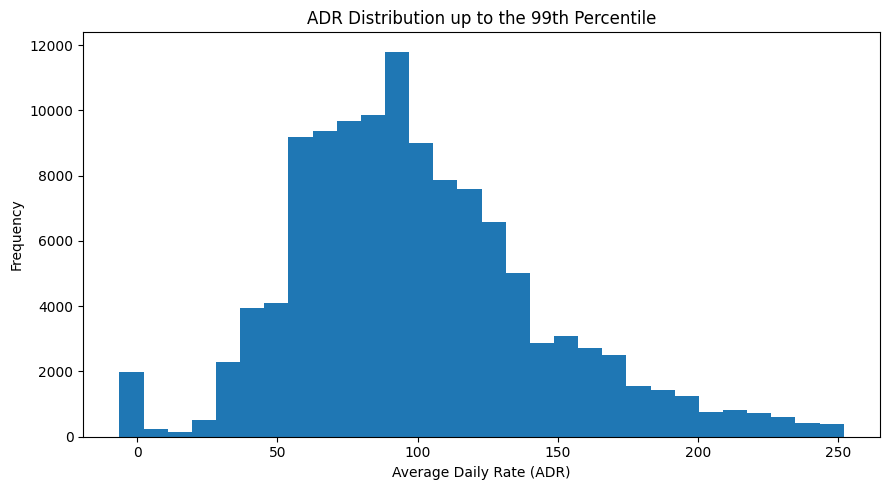

In [ ]:
# adr
adr_main = df.loc[
    df["adr"] <= df["adr"].quantile(0.99),
    "adr"
]

plt.figure(figsize=(9, 5))
plt.hist(adr_main.dropna(), bins=30)
plt.title("ADR Distribution up to the 99th Percentile")
plt.xlabel("Average Daily Rate (ADR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# selected extreme-value checks
extreme_summary = pd.DataFrame({
    "Check": [
        "Adults >= 10",
        "Children >= 5",
        "Babies >= 3",
        "Week nights >= 20",
        "ADR < 0",
        "ADR >= 500",
        "Parking spaces >= 3",
        "Zero total guests"
    ],
    "Count": [
        (df["adults"] >= 10).sum(),
        (df["children"] >= 5).sum(),
        (df["babies"] >= 3).sum(),
        (df["stays_in_week_nights"] >= 20).sum(),
        (df["adr"] < 0).sum(),
        (df["adr"] >= 500).sum(),
        (df["required_car_parking_spaces"] >= 3).sum(),
        (
            df["adults"].fillna(0)
            + df["children"].fillna(0)
            + df["babies"].fillna(0)
            == 0
        ).sum()
    ]
})
print("Selected Extreme and Suspicious Observations")
print(extreme_summary.to_string(index=False))

Selected Extreme and Suspicious Observations
              Check  Count
       Adults >= 10     13
      Children >= 5      1
        Babies >= 3      2
  Week nights >= 20     87
            ADR < 0      1
         ADR >= 500      3
Parking spaces >= 3      5
  Zero total guests    180


In [ ]:
print("Extreme ADR values:")
print(df.loc[(df["adr"] < 0) | (df["adr"] >= 500), ["adr", "hotel", "customer_type"]])

print("\nExtreme guest counts:")
print(
    df.loc[
        (df["adults"] >= 10) |
        (df["children"] >= 5) |
        (df["babies"] >= 3),
        ["adults", "children", "babies", "market_segment", "customer_type"]
    ]
)

Extreme ADR values:
            adr         hotel    customer_type
14969     -6.38  Resort Hotel  Transient-Party
15083    508.00  Resort Hotel        Transient
48515   5400.00    City Hotel        Transient
111403   510.00    City Hotel        Transient

Extreme guest counts:
       adults  children  babies market_segment    customer_type
328         2      10.0       0  Offline TA/TO         Contract
1539       40       0.0       0         Direct            Group
1587       26       0.0       0  Offline TA/TO            Group
1643       50       0.0       0         Direct            Group
1752       26       0.0       0  Offline TA/TO            Group
1884       26       0.0       0  Offline TA/TO            Group
1917       27       0.0       0         Direct            Group
1962       27       0.0       0         Direct            Group
2003       26       0.0       0  Offline TA/TO            Group
2164       26       0.0       0  Offline TA/TO            Group
2173       55     

## 3.3 Correlation and Class Imbalance

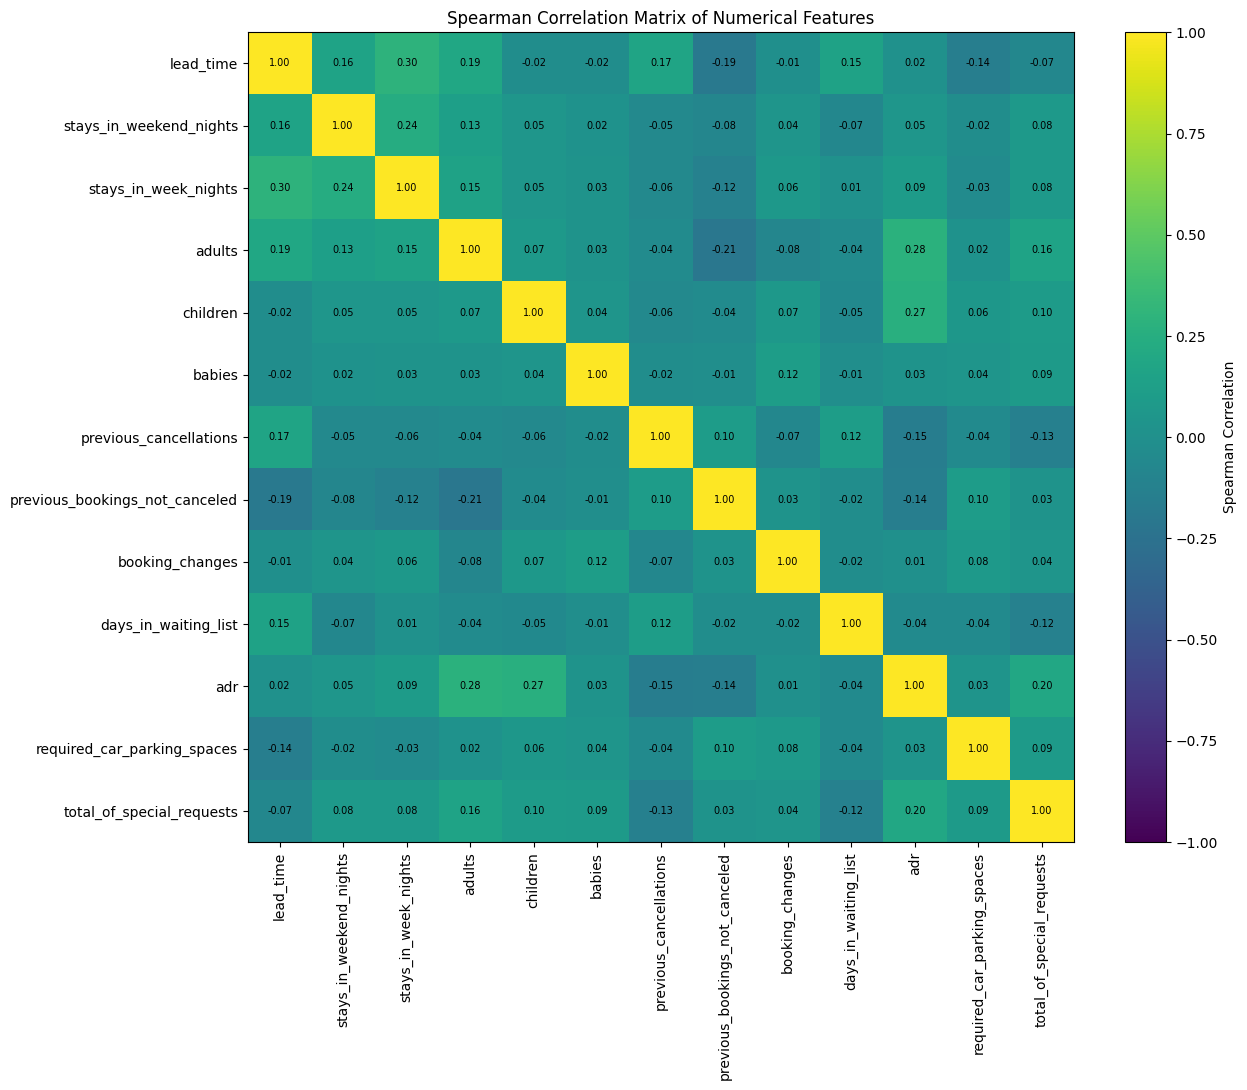

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define numeric_features using the existing 'features' list
numeric_features = features

corr = df[numeric_features].corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 11))

matrix = ax.imshow(
    corr,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(matrix, ax=ax, label="Spearman Correlation")

ax.set_xticks(range(len(numeric_features)))
ax.set_yticks(range(len(numeric_features)))

ax.set_xticklabels(numeric_features, rotation=90)
ax.set_yticklabels(numeric_features)

for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

ax.set_title("Spearman Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

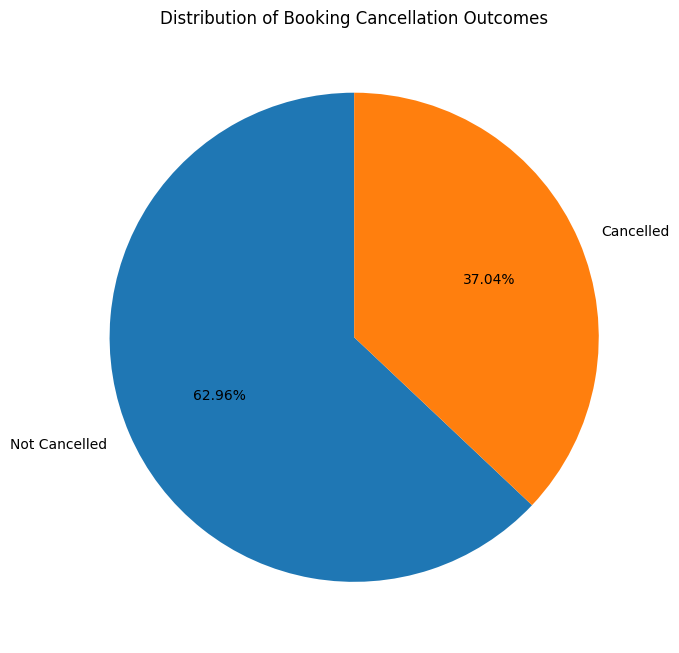

In [ ]:
# Cancellation class distribution

class_counts = df["is_canceled"].value_counts().sort_index()

plt.figure(figsize=(7, 7))

plt.pie(
    class_counts,
    labels=["Not Cancelled", "Cancelled"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Distribution of Booking Cancellation Outcomes")

plt.tight_layout()
plt.show()

In [ ]:
# create total stay length for descriptive comparison
df_hotel = df.copy()

df_hotel["total_stay_nights"] = (
    df_hotel["stays_in_weekend_nights"]
    + df_hotel["stays_in_week_nights"]
)

hotel_summary = (
    df_hotel.groupby("hotel")
    .agg(
        bookings=("hotel", "size"),
        positive_outcome_rate=("is_canceled", "mean"),
        lead_time_median=("lead_time", "median"),
        adr_median=("adr", "median"),
        total_stay_median=("total_stay_nights", "median"),
        special_requests_median=("total_of_special_requests", "median")
    )
)

hotel_summary["positive_outcome_rate"] *= 100
print(hotel_summary.round(2))

              bookings  positive_outcome_rate  lead_time_median  adr_median  \
hotel                                                                         
City Hotel       79330                  41.73              74.0        99.9   
Resort Hotel     40060                  27.76              57.0        75.0   

              total_stay_median  special_requests_median  
hotel                                                     
City Hotel                  3.0                      0.0  
Resort Hotel                3.0                      0.0  


## 3.4 Data Inconsistency and Leakage

In [ ]:
# check potentially inconsistent categorical values
print("Meal categories:")
print(df["meal"].value_counts(dropna=False))
print("\nMarket segment categories:")
print(df["market_segment"].value_counts(dropna=False))
print("\nDistribution channel categories:")
print(df["distribution_channel"].value_counts(dropna=False))
# Zero-guest bookings
zero_guest = (
    df["adults"].fillna(0)
    + df["children"].fillna(0)
    + df["babies"].fillna(0)
    == 0
)
print("\nZero-guest bookings:", zero_guest.sum())

Meal categories:
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

Market segment categories:
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

Distribution channel categories:
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

Zero-guest bookings: 180


In [ ]:
# count non-null unique categories
for col in ["country", "agent", "company"]:
    print(
        f"{col}: {df[col].nunique(dropna=True)} non-null categories"
    )

# count how many country categories appear fewer than 10 times
country_counts = df["country"].value_counts(dropna=True)

rare_country = country_counts[country_counts < 10]

print("\nCountry categories with fewer than 10 records:")
print(len(rare_country))

print("\nRare country categories:")
print(rare_country)

country: 177 non-null categories
agent: 333 non-null categories
company: 352 non-null categories

Country categories with fewer than 10 records:
81

Rare country categories:
country
PAN    9
TJK    9
GNB    9
ARM    8
JEY    8
      ..
MRT    1
KIR    1
SDN    1
ATF    1
SLE    1
Name: count, Length: 81, dtype: int64
